In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasad22/student-satisfaction-survey")

print("Path to dataset files:", path)

100%|██████████| 9.13k/9.13k [00:00<00:00, 15.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prasad22/student-satisfaction-survey/versions/1


In [ ]:
# List files in dataset directory
import os
os.listdir(path)


['Student_Satisfaction_Survey.csv']

In [ ]:
df = pd.read_csv("/content/sample_data/Student_Satisfaction_Survey.csv", encoding='latin1')
df.head()

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SN                    580 non-null    int64 
 1   Total Feedback Given  580 non-null    int64 
 2   Total Configured      580 non-null    int64 
 3   Questions             580 non-null    object
 4   Weightage 1           580 non-null    int64 
 5   Weightage 2           580 non-null    int64 
 6   Weightage 3           580 non-null    int64 
 7   Weightage 4           580 non-null    int64 
 8   Weightage 5           580 non-null    int64 
 9   Average/ Percentage   580 non-null    object
 10  Course Name           580 non-null    object
 11  Basic Course          580 non-null    object
dtypes: int64(8), object(4)
memory usage: 54.5+ KB


,SN,Total Feedback Given,Total Configured,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,10.500000,14.310345,92.517241,0.527586,1.187931,2.537931,5.082759,4.974138
std,5.771259,16.488031,114.491780,1.305336,1.686334,3.193302,7.288293,6.494931
min,1.000000,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.750000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,10.500000,7.000000,42.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,15.250000,17.000000,123.000000,1.000000,2.000000,3.250000,6.000000,6.000000
max,20.000000,74.000000,559.000000,19.000000,8.000000,26.000000,52.000000,38.000000


In [ ]:
# Check missing values
df.isnull().sum()


,0
SN,0
Total Feedback Given,0
Total Configured,0
Questions,0
Weightage 1,0
Weightage 2,0
Weightage 3,0
Weightage 4,0
Weightage 5,0
Average/ Percentage,0


In [ ]:
# Rename columns for simplicity
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Drop rows with missing values
df.dropna(inplace=True)

df.head()


,SN,Total_Feedback_Given,Total_Configured,Questions,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5,Average/_Percentage,Course_Name,Basic_Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


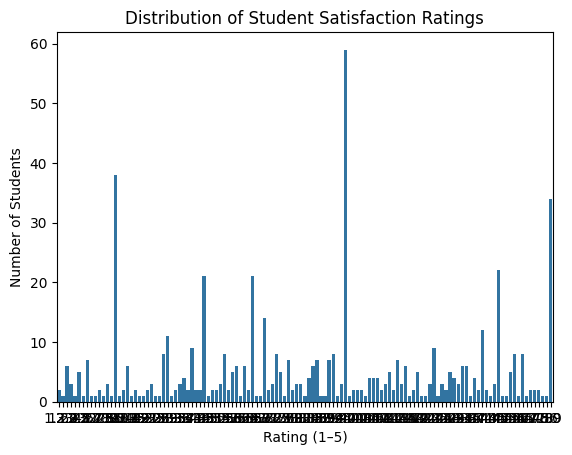

In [ ]:
df['Satisfaction_Rating'] = df['Average/_Percentage'].apply(lambda x: float(x.split('/')[0].strip()))
plt.figure()
sns.countplot(x="Satisfaction_Rating", data=df)
plt.title("Distribution of Student Satisfaction Ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
df["Satisfaction_Rating"].mean()


np.float64(3.842793103448275)

In [ ]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df["Sentiment_Score"] = df["Questions"].apply(get_sentiment)

In [ ]:
df.head()

,SN,Total_Feedback_Given,Total_Configured,Questions,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5,Average/_Percentage,Course_Name,Basic_Course,Satisfaction_Rating,Sentiment_Score
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,3.0,0.2
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,5.0,0.0
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,5.0,0.5
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,3.0,1.0
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,4.0,0.0


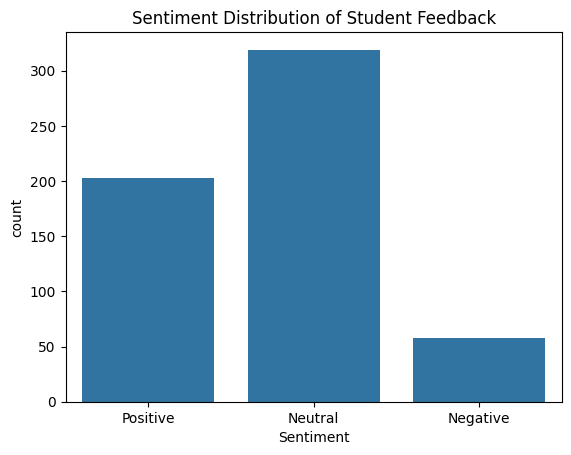

In [ ]:
# Create a categorical 'Sentiment' column from 'Sentiment_Score'
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment_Score'].apply(categorize_sentiment)

plt.figure()
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution of Student Feedback")
plt.show()

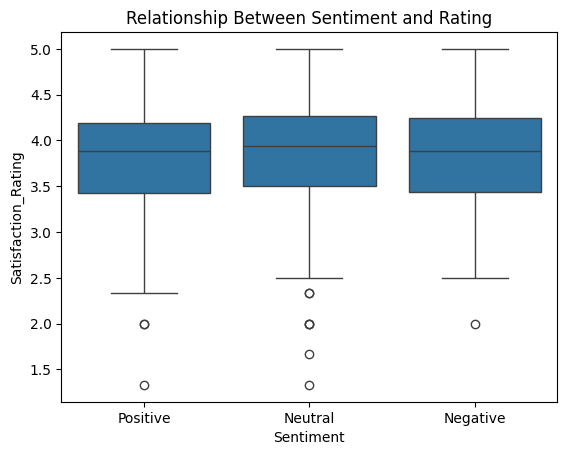

In [ ]:
sns.boxplot(x="Sentiment", y="Satisfaction_Rating", data=df)
plt.title("Relationship Between Sentiment and Rating")
plt.show()


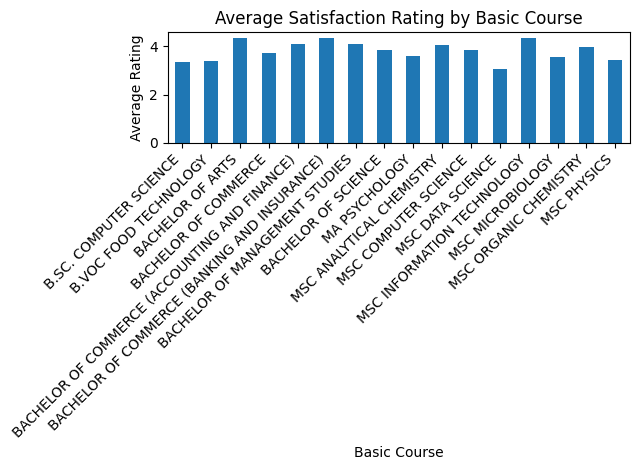

In [ ]:
dept_avg = df.groupby("Basic_Course")["Satisfaction_Rating"].mean()

dept_avg.plot(kind="bar")
plt.title("Average Satisfaction Rating by Basic Course")
plt.xlabel("Basic Course")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()